In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

In [29]:
model_df_cluster = pd.read_pickle("model_cluster.pkl")
model_df = model_df_cluster.copy()
model_df["STATE"] = model_df["STATE"].astype(str).str.strip()
model_df["COUNTY"] = model_df["COUNTY"].astype(str).str.strip().str.zfill(3)
model_df["date"] = pd.to_datetime(
    model_df["year"].astype(str) + "-" + model_df["month"].astype(str) + "-01"
)
model_df = model_df.sort_values(["STATE", "COUNTY", "date"]).reset_index(drop=True)


In [30]:
model_df["target"] = (model_df["notable_fire_count"] > 0).astype(int)
model_df["target_next_month"] = (
    model_df.groupby(["STATE", "COUNTY"])["target"].shift(-1)
)

In [31]:
model_df = model_df.dropna(subset=["target_next_month"]).copy()
model_df["target_next_month"] = model_df["target_next_month"].astype(int)

In [32]:
model_df["month_sin"] = np.sin(2 * np.pi * model_df["month"] / 12)
model_df["month_cos"] = np.cos(2 * np.pi * model_df["month"] / 12)

In [33]:
group_cols = ["STATE", "COUNTY"]
model_df["fire_count_lag1"] = model_df.groupby(group_cols)["fire_count"].shift(1)
model_df["notable_fire_count_lag1"] = model_df.groupby(group_cols)["notable_fire_count"].shift(1)
model_df["total_acres_lag1"] = model_df.groupby(group_cols)["total_acres"].shift(1)
model_df["max_fire_size_lag1"] = model_df.groupby(group_cols)["max_fire_size"].shift(1)
model_df["target_lag1"] = model_df.groupby(group_cols)["target"].shift(1)

In [34]:
model_df["target_lag12"] = model_df.groupby(group_cols)["target"].shift(12)
model_df["fire_count_lag12"] = model_df.groupby(group_cols)["fire_count"].shift(12)
model_df["total_acres_lag12"] = model_df.groupby(group_cols)["total_acres"].shift(12)

In [35]:
model_df["fire_roll3"] = (
    model_df.groupby(group_cols)["fire_count"]
    .transform(lambda s: s.shift(1).rolling(3, min_periods=1).sum())
)
model_df["fire_roll12"] = (
    model_df.groupby(group_cols)["fire_count"]
    .transform(lambda s: s.shift(1).rolling(12, min_periods=1).sum())
)
model_df["notable_roll3"] = (
    model_df.groupby(group_cols)["notable_fire_count"]
    .transform(lambda s: s.shift(1).rolling(3, min_periods=1).sum())
)
model_df["notable_roll12"] = (
    model_df.groupby(group_cols)["notable_fire_count"]
    .transform(lambda s: s.shift(1).rolling(12, min_periods=1).sum())
)
model_df["acres_roll3"] = (
    model_df.groupby(group_cols)["total_acres"]
    .transform(lambda s: s.shift(1).rolling(3, min_periods=1).sum())
)
model_df["acres_roll12"] = (
    model_df.groupby(group_cols)["total_acres"]
    .transform(lambda s: s.shift(1).rolling(12, min_periods=1).sum())
)
model_df["max_size_roll3"] = (
    model_df.groupby(group_cols)["max_fire_size"]
    .transform(lambda s: s.shift(1).rolling(3, min_periods=1).max())
)
model_df["max_size_roll12"] = (
    model_df.groupby(group_cols)["max_fire_size"]
    .transform(lambda s: s.shift(1).rolling(12, min_periods=1).max())
)

,STATE,COUNTY,date,year,month,fire_count,notable_fire_count,total_acres,max_fire_size,mean_fire_size,...,fire_count_lag12,total_acres_lag12,fire_roll3,fire_roll12,notable_roll3,notable_roll12,acres_roll3,acres_roll12,max_size_roll3,max_size_roll12
0,AK,020,1992-01-01,1992,1,0.0,0.0,0.0,0.0,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AK,020,1992-02-01,1992,2,0.0,0.0,0.0,0.0,0.000000,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
2,AK,020,1992-03-01,1992,3,0.0,0.0,0.0,0.0,0.000000,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
3,AK,020,1992-04-01,1992,4,0.0,0.0,0.0,0.0,0.000000,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
4,AK,020,1992-05-01,1992,5,0.0,0.0,0.0,0.0,0.000000,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1544250,WY,Weston,2015-07-01,2015,7,0.0,0.0,0.0,0.0,0.000000,...,17.0,30.49,0.0,29.0,0.0,0.0,0.0,55.52,0.0,24.7
1544251,WY,Weston,2015-08-01,2015,8,3.0,1.0,122.3,113.0,40.766667,...,9.0,23.63,0.0,12.0,0.0,0.0,0.0,25.03,0.0,5.7
1544252,WY,Weston,2015-09-01,2015,9,0.0,0.0,0.0,0.0,0.000000,...,2.0,0.40,3.0,6.0,1.0,1.0,122.3,123.70,113.0,113.0
1544253,WY,Weston,2015-10-01,2015,10,0.0,0.0,0.0,0.0,0.000000,...,1.0,1.00,3.0,4.0,1.0,1.0,122.3,123.30,113.0,113.0


In [43]:
df = pd.read_pickle("fire.pkl")
county_coords = (
    df.groupby(["STATE", "COUNTY"], as_index=False)
      .agg(
          LATITUDE=("LATITUDE", "mean"),
          LONGITUDE=("LONGITUDE", "mean")
      )
)


county_cluster_map = (
    model_df_cluster[["STATE", "COUNTY", "cluster"]]
    .drop_duplicates()
    .merge(county_coords, on=["STATE", "COUNTY"], how="left")
)

cluster_counts = county_cluster_map["cluster"].value_counts().sort_index()
cluster_counts
# Note: some of the county code naming are duplicate

low_fire_clusters = [0, 2]

cluster
0     648
1       2
2    4626
3      68
4      17
5       1
Name: count, dtype: int64

In [44]:
low_fire_clusters = [0, 2]

model_df["spatial_regime"] = np.where(
    model_df["cluster"].isin(low_fire_clusters),
    "low",
    "elevated"
)

In [59]:
model_df["spatial_regime"] = pd.Categorical(
    model_df["spatial_regime"],
    categories=["low", "elevated"]
)

In [60]:
model_df

,STATE,COUNTY,date,year,month,fire_count,notable_fire_count,total_acres,max_fire_size,mean_fire_size,...,total_acres_lag12,fire_roll3,fire_roll12,notable_roll3,notable_roll12,acres_roll3,acres_roll12,max_size_roll3,max_size_roll12,spatial_regime
0,AK,020,1992-01-01,1992,1,0.0,0.0,0.0,0.0,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,low
1,AK,020,1992-02-01,1992,2,0.0,0.0,0.0,0.0,0.000000,...,NaN,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,low
2,AK,020,1992-03-01,1992,3,0.0,0.0,0.0,0.0,0.000000,...,NaN,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,low
3,AK,020,1992-04-01,1992,4,0.0,0.0,0.0,0.0,0.000000,...,NaN,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,low
4,AK,020,1992-05-01,1992,5,0.0,0.0,0.0,0.0,0.000000,...,NaN,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1544250,WY,Weston,2015-07-01,2015,7,0.0,0.0,0.0,0.0,0.000000,...,30.49,0.0,29.0,0.0,0.0,0.0,55.52,0.0,24.7,low
1544251,WY,Weston,2015-08-01,2015,8,3.0,1.0,122.3,113.0,40.766667,...,23.63,0.0,12.0,0.0,0.0,0.0,25.03,0.0,5.7,low
1544252,WY,Weston,2015-09-01,2015,9,0.0,0.0,0.0,0.0,0.000000,...,0.40,3.0,6.0,1.0,1.0,122.3,123.70,113.0,113.0,low
1544253,WY,Weston,2015-10-01,2015,10,0.0,0.0,0.0,0.0,0.000000,...,1.00,3.0,4.0,1.0,1.0,122.3,123.30,113.0,113.0,low


In [66]:
model_df.columns
model_df.to_pickle("final_df.pkl")

Dropping first year and last year of data
first-pass XGBoost setup is:
objective="binary:logistic"
eval_metric="auc"
n_estimators around 200–400
moderate max_depth like 4 or 5
learning_rate around 0.05–0.1
subsample and colsample_bytree around 0.8

In [2]:
model_df=pd.read_pickle("final_df.pkl")
predictor_cols = [
    "year",
    "month_sin",
    "month_cos",
    "fire_count_lag1",
    "notable_fire_count_lag1",
    "target_lag12",
    "fire_roll3",
    "fire_roll12",
    "acres_roll3",
    "acres_roll12",
    "max_size_roll3",
    "max_size_roll12",
    "spatial_regime"
]
target_col = "target_next_month"
model_data = model_df.copy()
model_data = model_data.dropna(subset=predictor_cols + [target_col]).copy()

print(model_data.shape)
print(model_data[target_col].value_counts(normalize=True))

(1474550, 33)
target_next_month
0    0.983492
1    0.016508
Name: proportion, dtype: float64


In [3]:
model_xgb = pd.get_dummies(
    model_data,
    columns=["spatial_regime"],
    drop_first=True
)
x_cols = [c for c in model_xgb.columns if c in predictor_cols or c.startswith("spatial_regime_")]
x_cols = [c for c in x_cols if c != "spatial_regime"]
print(x_cols)

['year', 'month_sin', 'month_cos', 'fire_count_lag1', 'notable_fire_count_lag1', 'target_lag12', 'fire_roll3', 'fire_roll12', 'acres_roll3', 'acres_roll12', 'max_size_roll3', 'max_size_roll12', 'spatial_regime_elevated']


In [4]:
years_sorted = np.sort(model_xgb["year"].unique())
min_train_years = 3
results = []

In [ ]:
for i in range(min_train_years, len(years_sorted)):
    train_years = years_sorted[:i]
    valid_year = years_sorted[i]

    train_mask = model_xgb["year"].isin(train_years)
    valid_mask = model_xgb["year"] == valid_year

    train_df = model_xgb.loc[train_mask].copy()
    valid_df = model_xgb.loc[valid_mask].copy()

    X_train = train_df[x_cols]
    y_train = train_df[target_col]

    X_valid = valid_df[x_cols]
    y_valid = valid_df[target_col]

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_prob)

    results.append({
        "train_end_year": train_years.max(),
        "valid_year": valid_year,
        "auc_xgb": auc
    })

fold_results_xgb = pd.DataFrame(results)
fold_results_xgb.to_pickle("XGB.pkl")

In [6]:
fold_results_xgb

,train_end_year,valid_year,auc_xgb
0,1995,1996,0.961681
1,1996,1997,0.953507
2,1997,1998,0.947649
3,1998,1999,0.905677
4,1999,2000,0.940889
5,2000,2001,0.943812
6,2001,2002,0.869962
7,2002,2003,0.881327
8,2003,2004,0.893385
9,2004,2005,0.824719


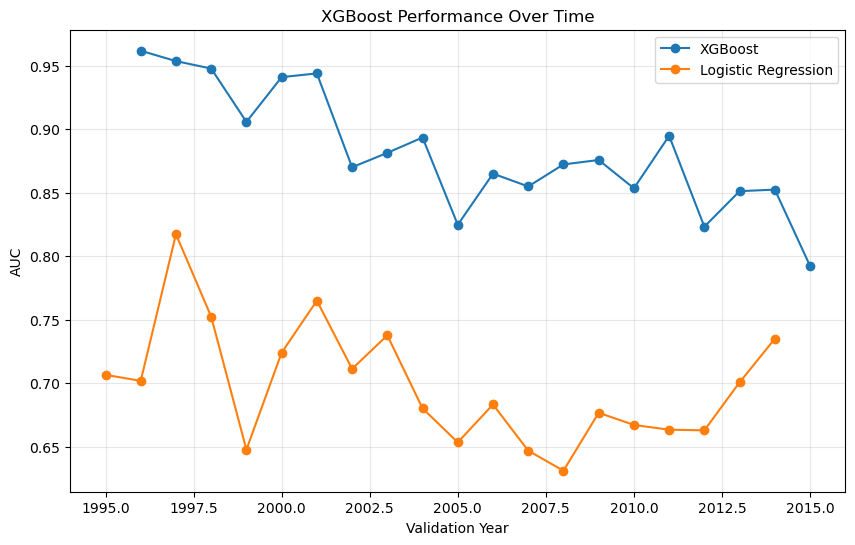

In [10]:
fold_results_xgb=pd.read_pickle("XGB.pkl")
fold_results = pd.read_csv("../Data/fold_results.csv")

plt.figure(figsize=(10,6))
plt.plot(fold_results_xgb["valid_year"], fold_results_xgb["auc_xgb"], marker="o", label="XGBoost")
plt.plot(fold_results["valid_year"], fold_results["auc_glm"], marker="o", label="Logistic Regression")
plt.xlabel("Validation Year")
plt.ylabel("AUC")
plt.title("XGBoost Performance Over Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
fold_results_xgb = fold_results_xgb.iloc[:20]

In [9]:
fold_results_xgb.to_pickle("XGB.pkl")

In [13]:
model_df = pd.read_pickle("model_cluster.pkl")
model_df



,STATE,COUNTY,date,year,month,fire_count,notable_fire_count,total_acres,max_fire_size,mean_fire_size,median_fire_size,target,cluster
0,AK,020,1992-01-01,1992,1,0.0,0.0,0.0,0.0,0.000000,0.0,0,2
1,AK,020,1992-02-01,1992,2,0.0,0.0,0.0,0.0,0.000000,0.0,0,2
2,AK,020,1992-03-01,1992,3,0.0,0.0,0.0,0.0,0.000000,0.0,0,2
3,AK,020,1992-04-01,1992,4,0.0,0.0,0.0,0.0,0.000000,0.0,0,2
4,AK,020,1992-05-01,1992,5,0.0,0.0,0.0,0.0,0.000000,0.0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1544251,WY,Weston,2015-08-01,2015,8,3.0,1.0,122.3,113.0,40.766667,4.8,1,0
1544252,WY,Weston,2015-09-01,2015,9,0.0,0.0,0.0,0.0,0.000000,0.0,0,0
1544253,WY,Weston,2015-10-01,2015,10,0.0,0.0,0.0,0.0,0.000000,0.0,0,0
1544254,WY,Weston,2015-11-01,2015,11,0.0,0.0,0.0,0.0,0.000000,0.0,0,0


In [16]:
model_df = model_df.sort_values(["STATE", "COUNTY", "date"]).reset_index(drop=True)
model_df["target"] = (model_df["notable_fire_count"] > 0).astype(int)

In [17]:
model_df

,STATE,COUNTY,date,year,month,fire_count,notable_fire_count,total_acres,max_fire_size,mean_fire_size,median_fire_size,target,cluster
0,AK,020,1992-01-01,1992,1,0.0,0.0,0.0,0.0,0.000000,0.0,0,2
1,AK,020,1992-02-01,1992,2,0.0,0.0,0.0,0.0,0.000000,0.0,0,2
2,AK,020,1992-03-01,1992,3,0.0,0.0,0.0,0.0,0.000000,0.0,0,2
3,AK,020,1992-04-01,1992,4,0.0,0.0,0.0,0.0,0.000000,0.0,0,2
4,AK,020,1992-05-01,1992,5,0.0,0.0,0.0,0.0,0.000000,0.0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1544251,WY,Weston,2015-08-01,2015,8,3.0,1.0,122.3,113.0,40.766667,4.8,1,0
1544252,WY,Weston,2015-09-01,2015,9,0.0,0.0,0.0,0.0,0.000000,0.0,0,0
1544253,WY,Weston,2015-10-01,2015,10,0.0,0.0,0.0,0.0,0.000000,0.0,0,0
1544254,WY,Weston,2015-11-01,2015,11,0.0,0.0,0.0,0.0,0.000000,0.0,0,0
